# INIT

In [ ]:
%pip install torch diffusers timm pillow huggingface-hub dictdot einops fairscale transformers==4.57.3 sentencepiece matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.3/266.3 kB 21.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 111.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.0 MB/s eta 0:00:00
  Created wheel for fairscale: filename=fairscale-0.4.13-py3-none-any.whl size=332207 sha256=f8c1b64aed39ea9f24edcdcc14c5b48fc1648a652b3ffd4906c4e2dc29141672
  Stored in directory: /root/.cache/pip/wheels/5a/88/aa/d84b2cf1bad6b273cbf661640141a82c7b9f496e024f80aac0
Successfully built fairscale
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0
  Atte

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch

torch.cuda.is_available()

True

In [4]:
from diffusers import DiffusionPipeline
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

pipeline = DiffusionPipeline.from_pretrained(
    "xiangjx/MuPaD-256",
    custom_pipeline="xiangjx/MuPaD-256",
    trust_remote_code=True,
)
pipeline.to(device)

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

pipeline.py: 0.00B [00:00, ?B/s]

This modeling file might require the following packages that were not found in your environment: musk, samplers, models, transformer. Run `pip install musk samplers models transformer`


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

...

sit.py: 0.00B [00:00, ?B/s]

This modeling file might require the following packages that were not found in your environment: musk, samplers, models, transformer. Run `pip install musk samplers models transformer`


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

The config attributes {'model_name': 'SiT-XL/2', 'class_dropout_prob': 0.1, 'use_cfg': True, 'fused_attn': True, 'qk_norm': False} were passed to SiT, but are not expected and will be ignored. Please verify your config.json configuration file.


SiTPipeline {
  "_class_name": "SiTPipeline",
  "_diffusers_version": "0.39.0",
  "_name_or_path": "xiangjx/MuPaD-256",
  "scheduler": [
    null,
    null
  ],
  "transformer": [
    "diffusers_modules.local.sit",
    "SiT"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [14]:
# Text-to-Image generation
prompt = "Stomach"

output_t2i = pipeline(
    prompt=prompt,
    modality="text",
    num_images_per_prompt=1,
    num_inference_steps=250,
    guidance_scale=2.5,
    guidance_high=0.75,
    guidance_low=0.0,
    mode="sde",
    path_type="linear",
    seed=42
)


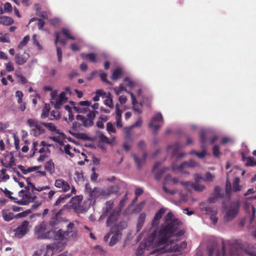

In [15]:
output_t2i["images"][0]


In [17]:
from PIL import Image
IMG_DIR = "/content/drive/MyDrive/syntheticdata/img"
# Load reference image
# Ensure you have a reference image path
raw_image = Image.open(f"{IMG_DIR}/im_512.png").convert("RGB")

output_i2i = pipeline(
    image=raw_image,
    modality="image",
    num_images_per_prompt=1,
    num_inference_steps=250,
    guidance_scale=2.5,
    guidance_high=0.75,
    guidance_low=0.0,
    mode="sde",
    path_type="linear",
    seed=42
)



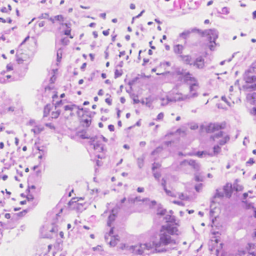

In [19]:
output_i2i["images"][0]